# Pitch Shot Analysis — 30 Practice vs 30 Real (45m pitch)

Files collected in alternating batches of 10. This is a much bigger swing motion than putting — should produce stronger acceleration signatures.

In [1]:
import fitparse
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
from scipy.signal import find_peaks

def load_fit(path):
    fitfile = fitparse.FitFile(path)
    records = []
    for record in fitfile.get_messages("record"):
        row = {}
        for field in record.fields:
            row[field.name] = field.value
        records.append(row)
    return pd.DataFrame(records)

def show_plot(fig, filename):
    fig.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=filename))

features = ['peak_mag', 'min_mag', 'mean_mag', 'std_mag', 'max_jerk', 'peak_x', 'peak_y', 'peak_z']

# Load and concatenate all 3 batches per type
practice_files = ['10 Practice.fit', '10 practice2.fit', '10Practice3.fit']
real_files = ['10 Real.fit', '10Real2.fit', '10Real3.fit']

def load_concat(files, label):
    dfs = []
    for f in files:
        d = load_fit(f).dropna(subset=['peak_mag']).reset_index(drop=True)
        d['batch'] = f
        dfs.append(d)
    df = pd.concat(dfs, ignore_index=True)
    df['elapsed'] = range(len(df))
    df['type'] = label
    return df

practice = load_concat(practice_files, 'practice')
real = load_concat(real_files, 'real')

print(f"Practice: {len(practice)} seconds across 3 batches")
print(f"Real:     {len(real)} seconds across 3 batches")
print(f"\nPractice peak_mag range: {practice['peak_mag'].min():.0f} - {practice['peak_mag'].max():.0f}")
print(f"Real peak_mag range:     {real['peak_mag'].min():.0f} - {real['peak_mag'].max():.0f}")

Practice: 250 seconds across 3 batches
Real:     603 seconds across 3 batches

Practice peak_mag range: 1018 - 6708
Real peak_mag range:     1018 - 6708


## Stroke Detection — Pitch Shots

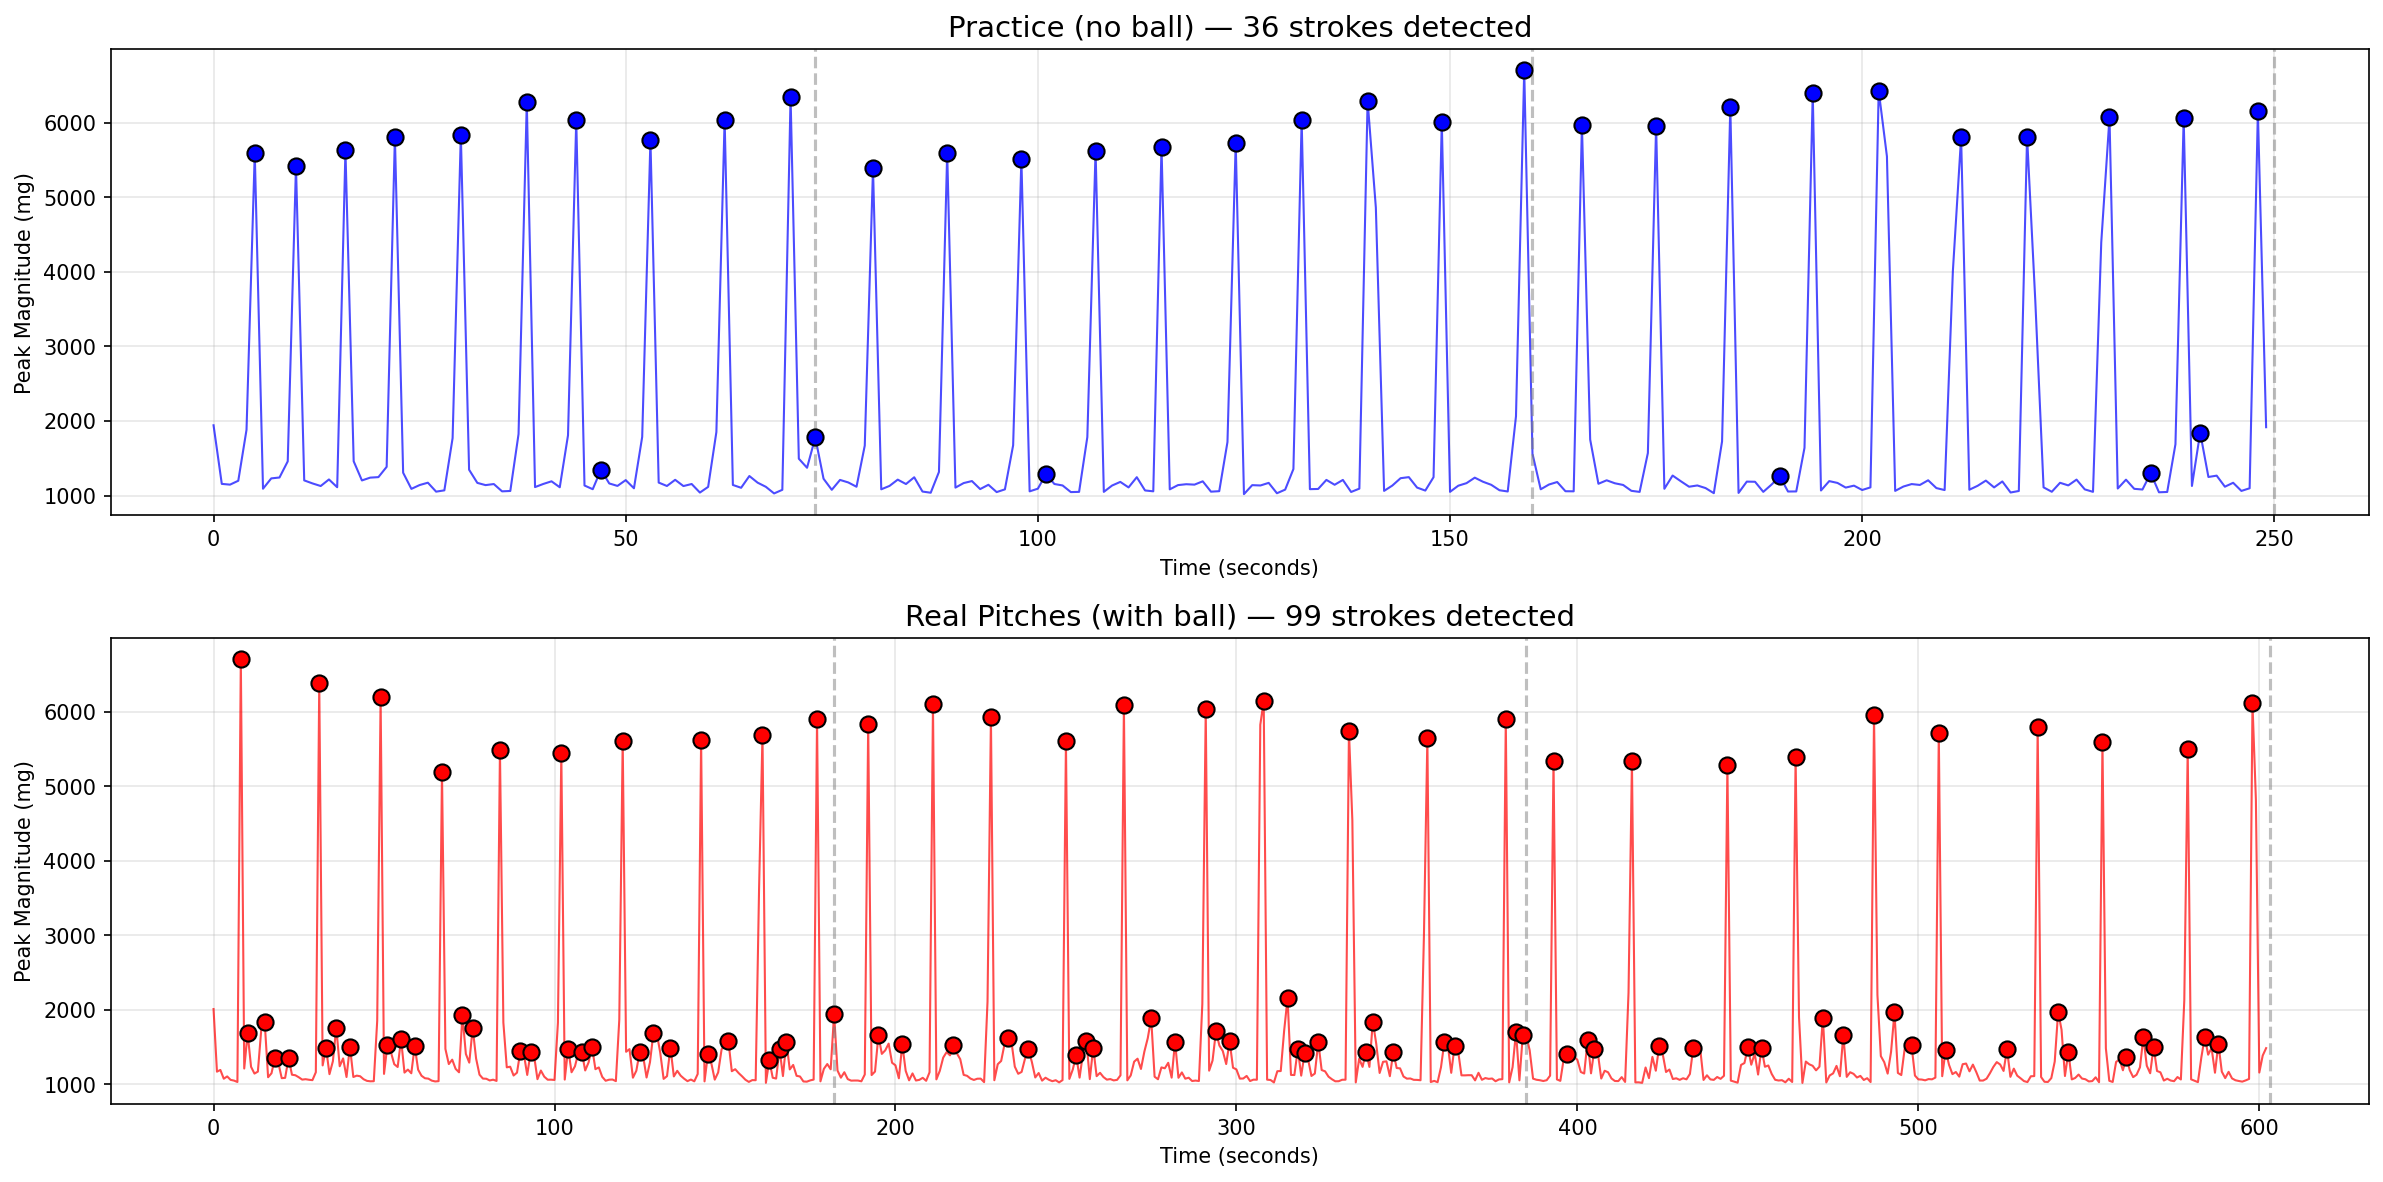

In [2]:
# Pitch shots are much bigger motion - higher prominence threshold
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

for i, (label, df, color) in enumerate([('Practice (no ball)', practice, 'blue'), ('Real Pitches (with ball)', real, 'red')]):
    mag = df['peak_mag'].values
    elapsed = df['elapsed'].values
    # Pitch shots much bigger than putts - use higher prominence
    peaks, _ = find_peaks(mag, distance=2, prominence=200)
    
    axes[i].plot(elapsed, mag, color=color, linewidth=1, alpha=0.7)
    axes[i].scatter(elapsed[peaks], mag[peaks], color=color, s=60, zorder=5, edgecolors='black', linewidth=1)
    
    # Mark batch boundaries
    cum = 0
    for f in (practice_files if label.startswith('Practice') else real_files):
        n = len(load_fit(f).dropna(subset=['peak_mag']))
        cum += n
        axes[i].axvline(x=cum, color='gray', linestyle='--', alpha=0.5)
    
    axes[i].set_title(f'{label} — {len(peaks)} strokes detected', fontsize=14)
    axes[i].set_ylabel('Peak Magnitude (mg)')
    axes[i].set_xlabel('Time (seconds)')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
show_plot(fig, 'pitch_stroke_detection.png')

## Pitch Shots vs Putts — Magnitude Comparison

Pitches should have *much* bigger acceleration than putts.

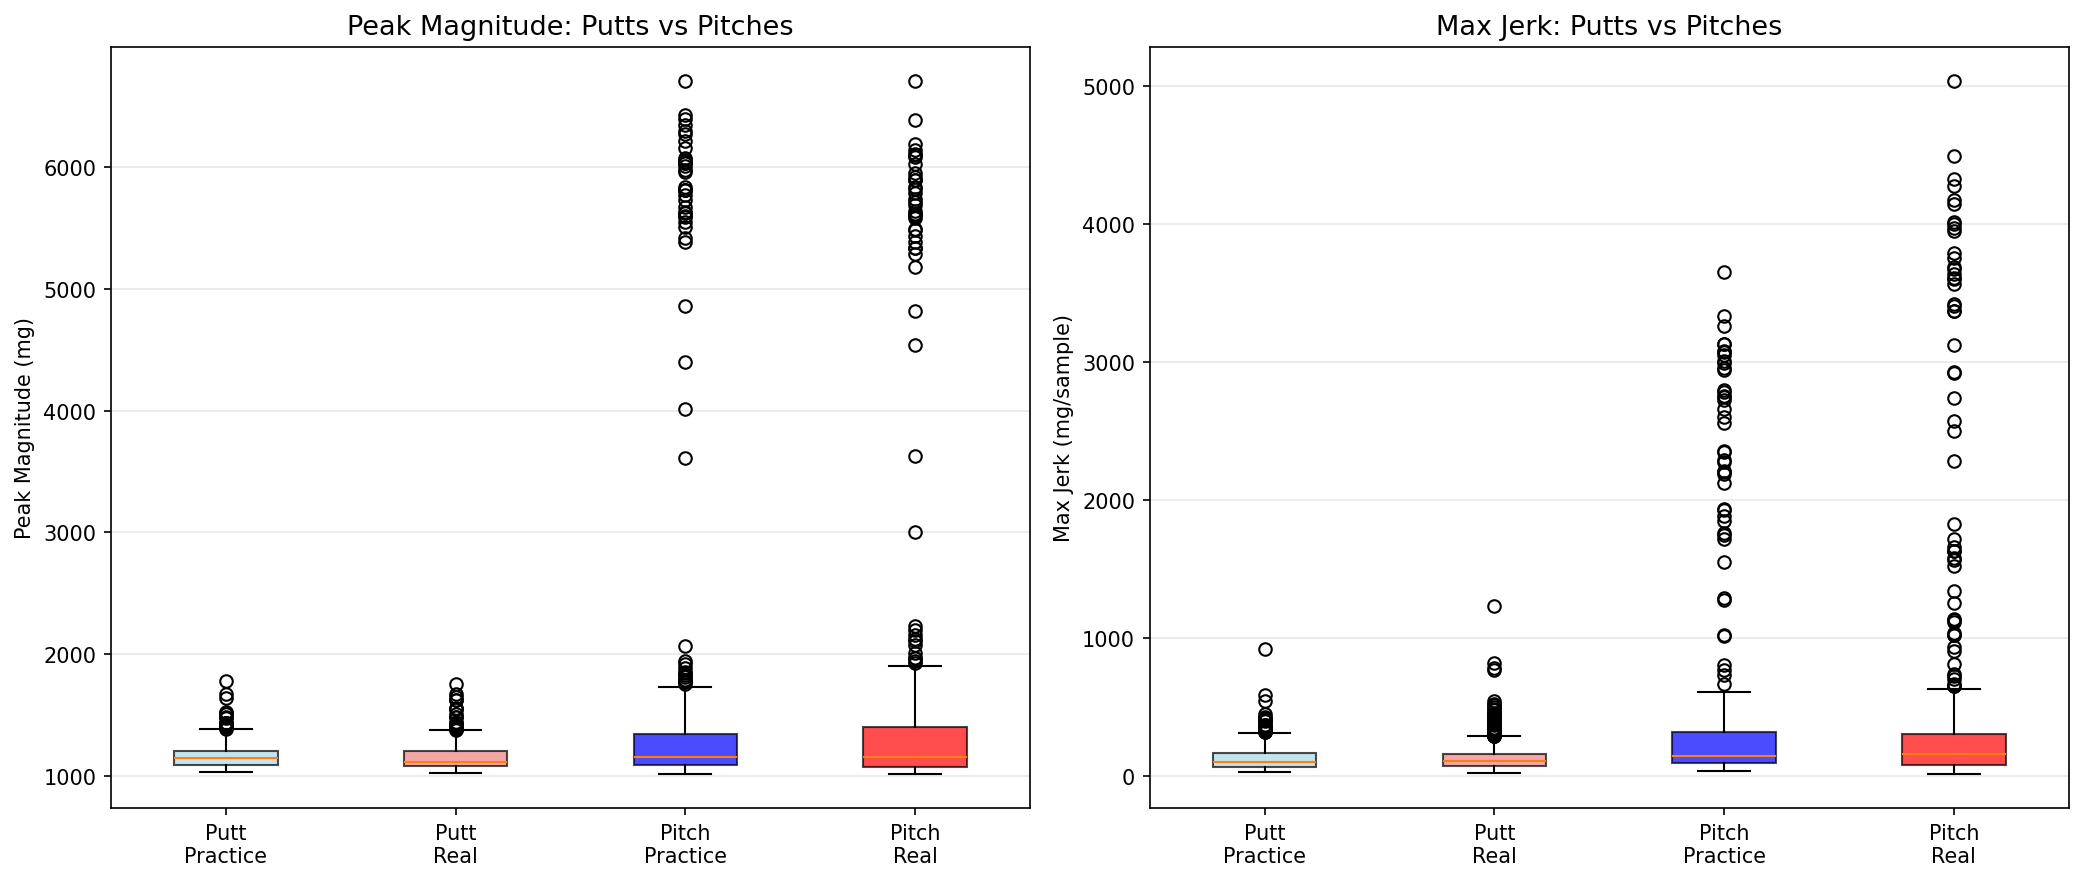

Mean peak_mag:
  Putt practice:  1163 mg
  Putt real:      1153 mg
  Pitch practice: 1839 mg
  Pitch real:     1480 mg

Max peak_mag:
  Putt practice:  1777 mg
  Putt real:      1758 mg
  Pitch practice: 6708 mg
  Pitch real:     6708 mg


In [3]:
# Load putt data for cross-comparison
putts_practice = load_fit('100 practice putts.fit').dropna(subset=['peak_mag']).reset_index(drop=True)
putts_real = load_fit('100 Real putts.fit').dropna(subset=['peak_mag']).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot of peak magnitude
data_to_plot = [
    putts_practice['peak_mag'].dropna(),
    putts_real['peak_mag'].dropna(),
    practice['peak_mag'].dropna(),
    real['peak_mag'].dropna(),
]
labels = ['Putt\nPractice', 'Putt\nReal', 'Pitch\nPractice', 'Pitch\nReal']
colors = ['lightblue', 'lightcoral', 'blue', 'red']

bp = axes[0].boxplot(data_to_plot, patch_artist=True, tick_labels=labels)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[0].set_title('Peak Magnitude: Putts vs Pitches', fontsize=13)
axes[0].set_ylabel('Peak Magnitude (mg)')
axes[0].grid(True, alpha=0.3, axis='y')

# Same for max_jerk
jerk_data = [
    putts_practice['max_jerk'].dropna(),
    putts_real['max_jerk'].dropna(),
    practice['max_jerk'].dropna(),
    real['max_jerk'].dropna(),
]
bp2 = axes[1].boxplot(jerk_data, patch_artist=True, tick_labels=labels)
for patch, c in zip(bp2['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[1].set_title('Max Jerk: Putts vs Pitches', fontsize=13)
axes[1].set_ylabel('Max Jerk (mg/sample)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
show_plot(fig, 'pitch_vs_putt.png')

print("Mean peak_mag:")
print(f"  Putt practice:  {putts_practice['peak_mag'].mean():.0f} mg")
print(f"  Putt real:      {putts_real['peak_mag'].mean():.0f} mg")
print(f"  Pitch practice: {practice['peak_mag'].mean():.0f} mg")
print(f"  Pitch real:     {real['peak_mag'].mean():.0f} mg")
print(f"\nMax peak_mag:")
print(f"  Putt practice:  {putts_practice['peak_mag'].max():.0f} mg")
print(f"  Putt real:      {putts_real['peak_mag'].max():.0f} mg")
print(f"  Pitch practice: {practice['peak_mag'].max():.0f} mg")
print(f"  Pitch real:     {real['peak_mag'].max():.0f} mg")

## ML: Pitch Practice vs Real Classification

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Detect strokes in pitch data
p_peaks, _ = find_peaks(practice['peak_mag'].values, distance=2, prominence=200)
r_peaks, _ = find_peaks(real['peak_mag'].values, distance=2, prominence=200)

p_strokes = practice.iloc[p_peaks][features].copy()
p_strokes['type'] = 'practice'
r_strokes = real.iloc[r_peaks][features].copy()
r_strokes['type'] = 'real'

print(f"Practice strokes: {len(p_strokes)} (target: 30)")
print(f"Real strokes:     {len(r_strokes)} (target: 30)")

all_strokes = pd.concat([p_strokes, r_strokes], ignore_index=True)
X = all_strokes[features].values
y = (all_strokes['type'] == 'real').astype(int).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"\nTrain: {len(y_train)}  Test: {len(y_test)}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'Random Forest': (RandomForestClassifier(random_state=42),
                      {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 10, None], 'min_samples_leaf': [1, 3, 5]}),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=42),
                          {'n_estimators': [50, 100, 200], 'max_depth': [2, 3, 5], 'learning_rate': [0.05, 0.1, 0.2]}),
    'SVM (RBF)': (SVC(kernel='rbf', random_state=42),
                  {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.01, 0.1, 1]}),
    'Logistic Regression': (LogisticRegression(max_iter=2000, random_state=42), {'C': [0.01, 0.1, 1, 10, 100]}),
    'KNN': (KNeighborsClassifier(), {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance']}),
}

results = {}
for name, (model, grid) in models.items():
    gs = GridSearchCV(model, grid, cv=cv, scoring='accuracy', n_jobs=-1)
    gs.fit(X_train_s, y_train)
    test_acc = gs.score(X_test_s, y_test)
    results[name] = {'best_params': gs.best_params_, 'cv_acc': gs.best_score_, 'test_acc': test_acc, 'estimator': gs.best_estimator_}
    print(f"\n{name}: CV={gs.best_score_:.1%}  Test={test_acc:.1%}  params={gs.best_params_}")

Practice strokes: 36 (target: 30)
Real strokes:     99 (target: 30)

Train: 94  Test: 41

Random Forest: CV=93.7%  Test=87.8%  params={'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100}

Gradient Boosting: CV=89.3%  Test=90.2%  params={'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}

SVM (RBF): CV=92.5%  Test=85.4%  params={'C': 100, 'gamma': 'scale'}

Logistic Regression: CV=85.1%  Test=90.2%  params={'C': 1}

KNN: CV=92.6%  Test=85.4%  params={'n_neighbors': 5, 'weights': 'distance'}



Random Forest: CV=93.7%  Test=87.8%  params={'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100}



Gradient Boosting: CV=89.3%  Test=90.2%  params={'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}

SVM (RBF): CV=92.5%  Test=85.4%  params={'C': 100, 'gamma': 'scale'}

Logistic Regression: CV=85.1%  Test=90.2%  params={'C': 1}

KNN: CV=92.6%  Test=85.4%  params={'n_neighbors': 5, 'weights': 'distance'}


## Multi-Class: Putt vs Pitch vs No-Stroke (4-class classification)

Can the model tell what *kind* of shot you took, not just whether a ball was involved?

label
putt_real         126
putt_practice     107
pitch_real         99
pitch_practice     36
Name: count, dtype: int64

4-class accuracy: 77.5%

Classification Report:
                precision    recall  f1-score   support

pitch_practice       0.80      0.73      0.76        11
    pitch_real       0.82      0.90      0.86        30
 putt_practice       0.75      0.66      0.70        32
     putt_real       0.75      0.79      0.77        38

      accuracy                           0.77       111
     macro avg       0.78      0.77      0.77       111
  weighted avg       0.77      0.77      0.77       111



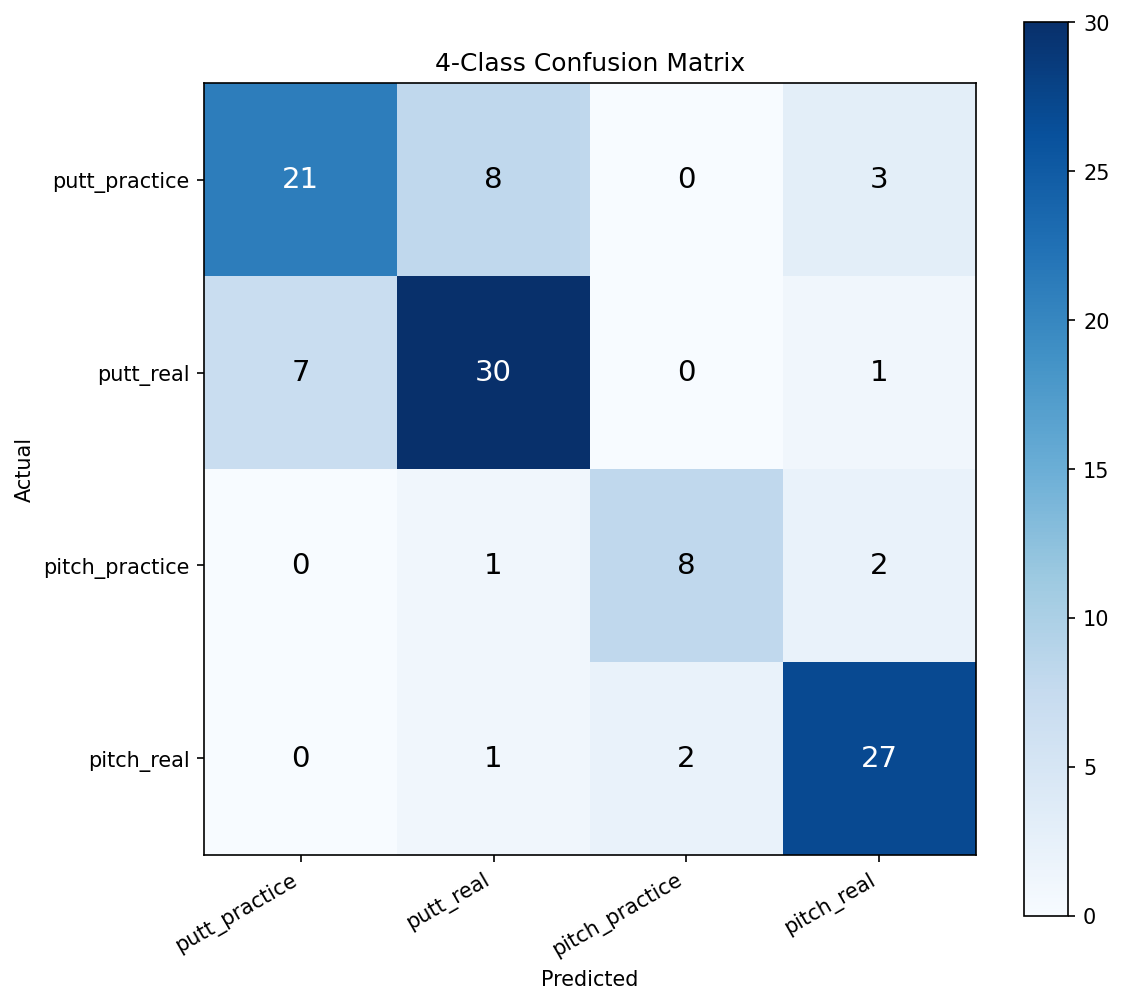

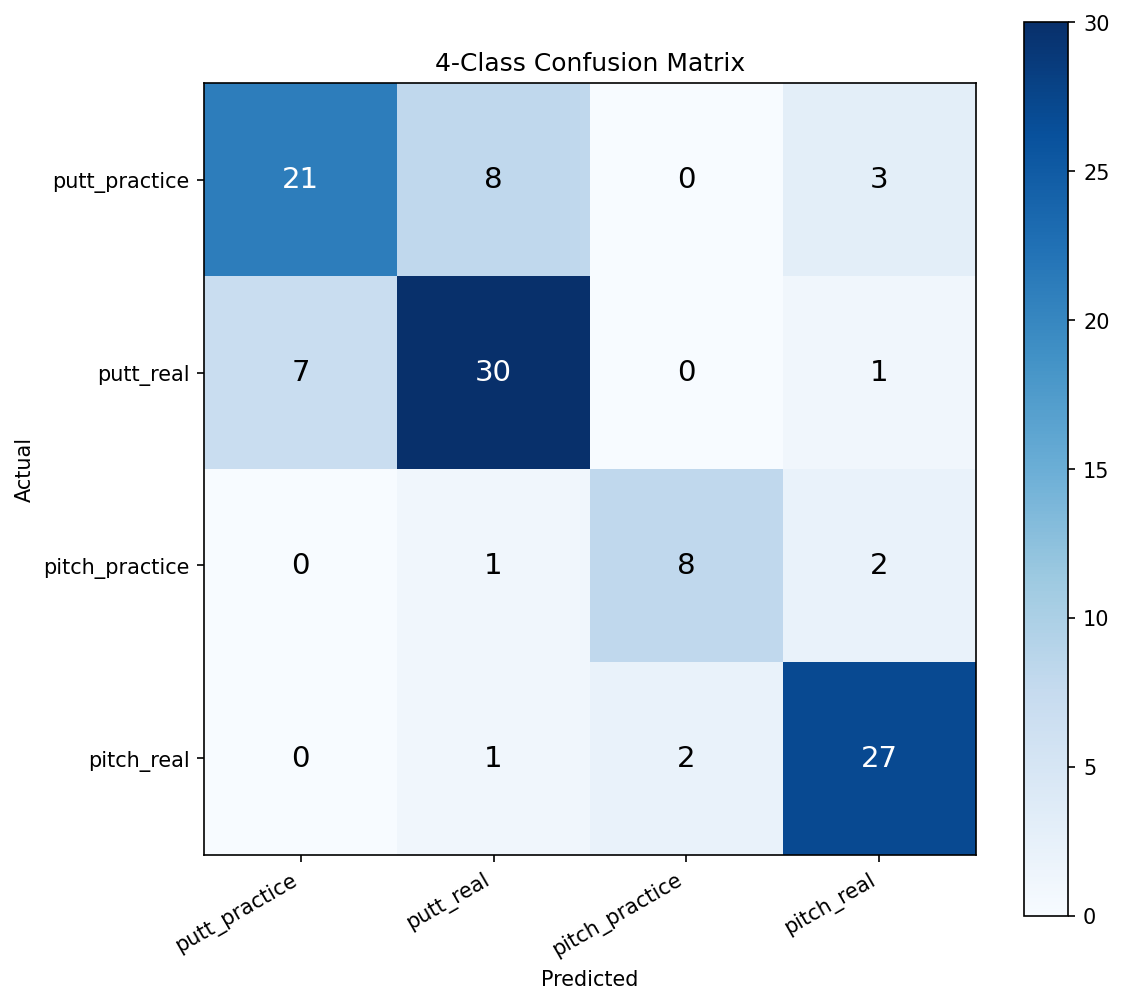

In [5]:
# Build a 4-class dataset: putt_practice, putt_real, pitch_practice, pitch_real
putt_p_peaks, _ = find_peaks(putts_practice['peak_mag'].values, distance=3, prominence=50)
putt_r_peaks, _ = find_peaks(putts_real['peak_mag'].values, distance=3, prominence=50)

s1 = putts_practice.iloc[putt_p_peaks][features].copy(); s1['label'] = 'putt_practice'
s2 = putts_real.iloc[putt_r_peaks][features].copy();     s2['label'] = 'putt_real'
s3 = practice.iloc[p_peaks][features].copy();            s3['label'] = 'pitch_practice'
s4 = real.iloc[r_peaks][features].copy();                s4['label'] = 'pitch_real'

multi = pd.concat([s1, s2, s3, s4], ignore_index=True)
print(multi['label'].value_counts())

X = multi[features].values
y = multi['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Quick RF (no grid search, just get a baseline)
clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
clf.fit(X_train_s, y_train)
y_pred = clf.predict(X_test_s)
print(f"\n4-class accuracy: {accuracy_score(y_test, y_pred):.1%}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = ['putt_practice', 'putt_real', 'pitch_practice', 'pitch_real']
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('4-Class Confusion Matrix')
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i][j], ha='center', va='center',
                color='white' if cm[i][j] > cm.max()/2 else 'black', fontsize=14)
plt.colorbar(im, ax=ax)
plt.tight_layout()
show_plot(fig, 'pitch_4class_cm.png')